In [1]:
!pip install timm umap-learn -q

In [3]:
import os
import numpy as np
import pandas as pd

from pathlib import Path

from PIL import Image

import matplotlib.pyplot as plt

import torch

from torchvision import transforms
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import timm

from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns

In [4]:
BASE_DIR = Path(
    "/content/drive/MyDrive/AI Work/screw/screw"
)

TRAIN_DIR = BASE_DIR / "train"

TEST_DIR = BASE_DIR / "test"

In [5]:
train_rows = []

good_dir = TRAIN_DIR / "good"

for img in good_dir.glob("*.png"):

    train_rows.append(
        [str(img)]
    )

train_df = pd.DataFrame(
    train_rows,
    columns=["image_path"]
)

print(train_df.shape)

train_df.head()

(320, 1)


,image_path
0,/content/drive/MyDrive/AI Work/screw/screw/tra...
1,/content/drive/MyDrive/AI Work/screw/screw/tra...
2,/content/drive/MyDrive/AI Work/screw/screw/tra...
3,/content/drive/MyDrive/AI Work/screw/screw/tra...
4,/content/drive/MyDrive/AI Work/screw/screw/tra...


In [6]:
test_rows = []

for defect_dir in TEST_DIR.iterdir():

    if defect_dir.is_dir():

        for img in defect_dir.glob("*.png"):

            label = 0 if defect_dir.name == "good" else 1

            test_rows.append(
                [
                    str(img),
                    defect_dir.name,
                    label
                ]
            )

test_df = pd.DataFrame(
    test_rows,
    columns=[
        "image_path",
        "defect_type",
        "label"
    ]
)

print(test_df.shape)

test_df.head()

(160, 3)


,image_path,defect_type,label
0,/content/drive/MyDrive/AI Work/screw/screw/tes...,thread_top,1
1,/content/drive/MyDrive/AI Work/screw/screw/tes...,thread_top,1
2,/content/drive/MyDrive/AI Work/screw/screw/tes...,thread_top,1
3,/content/drive/MyDrive/AI Work/screw/screw/tes...,thread_top,1
4,/content/drive/MyDrive/AI Work/screw/screw/tes...,thread_top,1


In [7]:
test_df.defect_type.value_counts()

,count
defect_type,
good,41
scratch_neck,25
scratch_head,24
manipulated_front,24
thread_side,23
thread_top,23


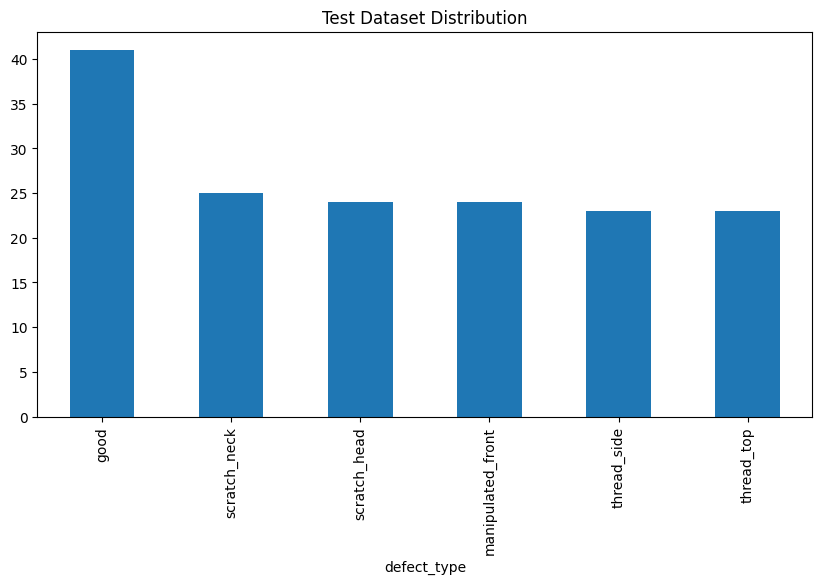

In [8]:
plt.figure(figsize=(10,5))

test_df.defect_type.value_counts().plot(
    kind="bar"
)

plt.title(
    "Test Dataset Distribution"
)

plt.show()

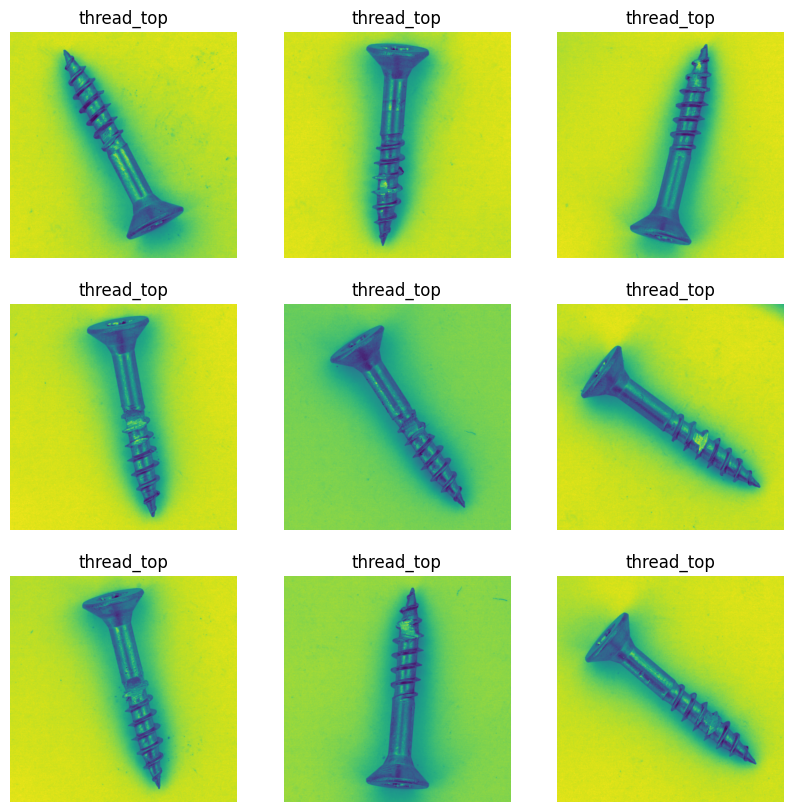

In [10]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(10,10)
)

for ax, idx in zip(
    axes.flatten(),
    range(9)
):

    img = Image.open(
        test_df.image_path.iloc[idx]
    )

    ax.imshow(img)

    ax.set_title(
        test_df.defect_type.iloc[idx]
    )

    ax.axis("off")

plt.show()

In [22]:
transform = transforms.Compose([
    transforms.Resize((518,518)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [23]:
class ScrewDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = dataframe

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(
        self,
        idx
    ):

        img = Image.open(
            self.df.iloc[idx]["image_path"]
        )

        img = img.convert(
            "RGB"
        )

        img = self.transform(
            img
        )

        return img

In [24]:
train_dataset = ScrewDataset(
    train_df,
    transform
)

test_dataset = ScrewDataset(
    test_df,
    transform
)

In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [26]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(device)

cpu


In [27]:
backbone = timm.create_model(
    "vit_base_patch14_dinov2",
    pretrained=True
)

In [28]:
backbone.reset_classifier(
    0
)

In [29]:
backbone = backbone.to(
    device
)

backbone.eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (q_norm): Identity()
        (k_norm): Identity()
        (attn_drop): Dropout(p=0.0, inplace=False)
        (norm): Identity()
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.0, inplace=Fal

In [30]:
dummy = torch.randn(
    1,
    3,
    224,
    224
).to(device)

with torch.no_grad():

    emb = backbone(dummy)

print(
    emb.shape
)

AssertionError: Input height (224) doesn't match model (518).

In [31]:
train_embeddings = []

In [32]:
with torch.no_grad():

    for images in train_loader:

        images = images.to(
            device
        )

        emb = backbone(
            images
        )

        train_embeddings.append(
            emb.cpu().numpy()
        )

KeyboardInterrupt: 

In [ ]:
train_embeddings = np.concatenate(
    train_embeddings,
    axis=0
)

print(
    train_embeddings.shape
)

In [ ]:
test_embeddings = []

In [ ]:
with torch.no_grad():

    for images in test_loader:

        images = images.to(
            device
        )

        emb = backbone(
            images
        )

        test_embeddings.append(
            emb.cpu().numpy()
        )

In [ ]:
test_embeddings = np.concatenate(
    test_embeddings,
    axis=0
)

print(
    test_embeddings.shape
)

In [ ]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

iso.fit(
    train_embeddings
)

In [ ]:
pred = iso.predict(
    test_embeddings
)

In [ ]:
pred = np.where(
    pred == -1,
    1,
    0
)

In [ ]:
print(
    classification_report(
        test_df.label,
        pred
    )
)

In [ ]:
cm = confusion_matrix(
    test_df.label,
    pred
)

In [ ]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

In [ ]:
scores = iso.decision_function(
    test_embeddings
)

In [ ]:
test_df[
    "anomaly_score"
] = scores

In [ ]:
test_df.sort_values(
    "anomaly_score"
).head()

In [ ]:
worst = test_df.sort_values(
    "anomaly_score"
).head(9)

In [ ]:
fig, axes = plt.subplots(
    3,
    3,
    figsize=(10,10)
)

for ax, (_, row) in zip(
    axes.flatten(),
    worst.iterrows()
):

    img = Image.open(
        row.image_path
    )

    ax.imshow(img)

    ax.set_title(
        row.defect_type
    )

    ax.axis("off")

plt.show()

In [ ]:
import umap

In [ ]:
reducer = umap.UMAP(
    random_state=42
)

In [ ]:
combined = np.vstack(
    [
        train_embeddings,
        test_embeddings
    ]
)

In [ ]:
embedding_2d = reducer.fit_transform(
    combined
)

In [ ]:
plt.figure(
    figsize=(10,8)
)

plt.scatter(
    embedding_2d[:,0],
    embedding_2d[:,1],
    alpha=0.5
)

plt.title(
    "Visual Embedding Space"
)

plt.show()

In [ ]:
np.save(
    "visual_train_embeddings.npy",
    train_embeddings
)

np.save(
    "visual_test_embeddings.npy",
    test_embeddings
)

In [ ]:
import joblib

joblib.dump(
    iso,
    "visual_isolation_forest.pkl"
)

In [ ]:
torch.save(
    backbone.state_dict(),
    "dinov2_visual_encoder.pth"
)